## Example of how you can use the `rmai-verification` API in a notebook

In [1]:
import sys
import os

# This is needed now, because the software is not yet installed as a package
module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path)

# Activate the logging in the notebook
import logging
LOG_FORMAT = "%(asctime)s - %(levelname)s - %(message)s"
DATE_FORMAT = "%Y-%m-%d %H:%M:%S"

logging.basicConfig(stream=sys.stdout, level=logging.DEBUG, format=LOG_FORMAT, datefmt=DATE_FORMAT)

### Data loading

In [2]:
from datastores import AnemoiDatasets, PointObservations

In [3]:
# Load the CERRA data, which is stored as an anemoi-datasets
cerra = AnemoiDatasets(
    files="/scratch/project_465001235/datasets/cerra-rr-an-oper-0001-mars-5p5km-1984-2020-3h-v2-rmi.zarr", # The files to open (only 1 in case of a anemoi-datasets)
    mapping="cerra" # Add projection and grid information to the datastore (CERRA is predifined, can also be a dictionary with grid and projection information)
)

# Load the SYNOP stations, which are stored as a rmai-verification complient netCDF-file 
synop = PointObservations(files="../../verification/cerra_synops_2020.nc")



2025-02-24 15:17:44 - INFO - Initializing AnemoiDataset datastore
2025-02-24 15:17:56 - DEBUG - eccodes lib search: trying to find binary wheel
2025-02-24 15:17:56 - DEBUG - eccodes lib search: looking in /scratch/project_465001235/vanginde/rmai-verification/venv/lib/python3.11/site-packages/eccodes.libs
2025-02-24 15:17:56 - DEBUG - eccodes lib search: returning wheel library from /scratch/project_465001235/vanginde/rmai-verification/venv/lib/python3.11/site-packages/eccodes.libs/libeccodes-e85d471c.so
2025-02-24 15:17:58 - DEBUG - eccodes lib search: versions: {'eccodes': '2.39.0'}
2025-02-24 15:18:06 - DEBUG - Registering codec 'zlib'
2025-02-24 15:18:07 - DEBUG - Registering codec 'gzip'
2025-02-24 15:18:07 - DEBUG - Registering codec 'bz2'
2025-02-24 15:18:07 - DEBUG - Registering codec 'lzma'
2025-02-24 15:18:07 - DEBUG - Registering codec 'blosc'
2025-02-24 15:18:07 - DEBUG - Registering codec 'zstd'
2025-02-24 15:18:07 - DEBUG - Registering codec 'lz4'
2025-02-24 15:18:07 - DEB

In [4]:
# Print the variables available in the cerra datastore
print(cerra.vars)

['10u_10' '10v_10' '2d_2' '2t_2' 'al' 'lsm' 'msl_0' 'orog' 'q_100'
 'q_1000' 'q_150' 'q_200' 'q_250' 'q_300' 'q_400' 'q_50' 'q_500' 'q_600'
 'q_700' 'q_850' 'q_925' 'rsn' 'sde' 'skt' 'sp' 't_100' 't_1000' 't_150'
 't_200' 't_250' 't_300' 't_400' 't_50' 't_500' 't_600' 't_700' 't_850'
 't_925' 'tcc_0' 'tciwv_0' 'tp' 'u_100' 'u_1000' 'u_150' 'u_200' 'u_250'
 'u_300' 'u_400' 'u_50' 'u_500' 'u_600' 'u_700' 'u_850' 'u_925' 'v_100'
 'v_1000' 'v_150' 'v_200' 'v_250' 'v_300' 'v_400' 'v_50' 'v_500' 'v_600'
 'v_700' 'v_850' 'v_925' 'z_100' 'z_1000' 'z_150' 'z_200' 'z_250' 'z_300'
 'z_400' 'z_50' 'z_500' 'z_600' 'z_700' 'z_850' 'z_925']


In [5]:
# Print the variables available in the synop datastore
print(synop.vars)

['10wdir', '10si', '2t', '2d', 'msl', '2r', '2t_max', '2t_min']


In [21]:
# When instanciated as a DataStore, the data the predescribed dimensions and coordinate-names
print("For gridded observations:")
print(" - Dimensions:")
print(synop.dims)
print(" - Coordinates:")
#print(cerra._data.coords) #The fact that I have to use ._data.coords here is the result of some missing functionality



For gridded observations:
 - Dimensions:
{'code': 1706, 'valid_time': 1}
 - Coordinates:


### Apply some transformations

In [7]:
from transformations import Renamer, UVToSpeed, KelvinToCelcius

In [8]:
# Lets rename some variables
rename = Renamer(
    {
        "10u" : ["10u_10", "U10m"], # The key is the new names are the old names or a list of the old names, so the transformation can be apllied to multiple datastores
        "10v": "10v_10",
        "2t": "2t_2",
        "2d": "2d_2"
    }
)

# Convert U & V components to wind speed
to_speed = UVToSpeed(u="10u", v="10v", speed="10si")

# Convert Kelvin to Celcius
to_celcius = KelvinToCelcius(fields="2t")

In [9]:
# Apply the transformations
cerra.transform(rename)
cerra.transform(to_speed)
cerra.transform(to_celcius)


2025-02-24 15:18:35 - DEBUG - Using AnemoiDatasets specific Renamer transformation
2025-02-24 15:18:35 - DEBUG - Using AnemoiDatasets specific UVToSpeed transformation
2025-02-24 15:18:48 - DEBUG - Transforming an xr.DataArray


### Subsetting the data

In [10]:
# Make a subselection in the CERRA datastore
cerra.select_variables(["2t","10si"])
cerra.select_valid_times(["2020-01-01T12:00:00"])

In [11]:
# Do the same for the SYNOP datastore
synop.select_variables(cerra.vars)
synop.select_valid_times(cerra.valid_times)


### Let's inspect the data

In [12]:
synop.data

<xarray.Dataset> Size: 355kB
Dimensions:          (code: 1706, valid_time: 1)
Coordinates:
  * code             (code) int64 14kB 1203 1205 1209 1210 ... 26961 26966 26976
  * valid_time       (valid_time) datetime64[ns] 8B 2020-01-01T12:00:00
    station_name     (code) <U20 136kB ...
    station_country  (code) <U20 136kB ...
    latitude         (code) float64 14kB ...
    longitude        (code) float64 14kB ...
    altitude         (code) float64 14kB ...
Data variables:
    2t               (code, valid_time) float64 14kB ...
    10si             (code, valid_time) float64 14kB ...

In [13]:
cerra.data

2025-02-24 15:18:57 - INFO - Transforming anemoi-datasets xr.DataArray to xr.Dataset, this might take some time.


<xarray.Dataset> Size: 55MB
Dimensions:     (valid_time: 1, grid_index: 1142761)
Coordinates:
    longitude   (grid_index) float32 5MB -17.49 -17.44 -17.4 ... 74.04 74.11
    latitude    (grid_index) float32 5MB 20.29 20.31 20.32 ... 63.84 63.81 63.77
  * valid_time  (valid_time) datetime64[ns] 8B 2020-01-01T12:00:00
  * grid_index  (grid_index) object 9MB MultiIndex
  * y           (grid_index) float64 9MB -2.937e+06 -2.937e+06 ... 2.932e+06
  * x           (grid_index) float64 9MB -2.937e+06 -2.931e+06 ... 2.932e+06
Data variables:
    2t          (valid_time, grid_index) float64 9MB dask.array<chunksize=(1, 1142761), meta=np.ndarray>
    10si        (valid_time, grid_index) float64 9MB dask.array<chunksize=(1, 1142761), meta=np.ndarray>
Attributes:
    crs:      +proj=lcc +ellps=WGS84 +a=6371229.0 +b=6371229.0 +lon_0=8.0 +la...

### Unstacking a GriddDatastore

In [14]:
# CERRA is a gridded dataset stacked to have a 1-D spatial dimension
# Lets unstack it to have 2-D spatial dimension (to do this a mapping must be provided here or when initializing the datastore)
cerra.unstack()
# The CERRA datastore is now 2D with x and y coordinates
cerra.data

2025-02-24 15:18:58 - INFO - Transforming anemoi-datasets xr.DataArray to xr.Dataset, this might take some time.


<xarray.Dataset> Size: 27MB
Dimensions:     (valid_time: 1, x: 1069, y: 1069)
Coordinates:
  * y           (y) float64 9kB -2.937e+06 -2.932e+06 ... 2.926e+06 2.932e+06
  * x           (x) float64 9kB -2.937e+06 -2.931e+06 ... 2.926e+06 2.932e+06
    longitude   (x, y) float32 5MB -17.49 -17.5 -17.52 ... 73.94 74.02 74.11
    latitude    (x, y) float32 5MB 20.29 20.33 20.38 20.42 ... 63.71 63.74 63.77
  * valid_time  (valid_time) datetime64[ns] 8B 2020-01-01T12:00:00
Data variables:
    2t          (valid_time, x, y) float64 9MB dask.array<chunksize=(1, 1069, 1069), meta=np.ndarray>
    10si        (valid_time, x, y) float64 9MB dask.array<chunksize=(1, 1069, 1069), meta=np.ndarray>
Attributes:
    crs:      +proj=lcc +ellps=WGS84 +a=6371229.0 +b=6371229.0 +lon_0=8.0 +la...

### Use the datastores for plotting

In [15]:
import cartopy 
# When you have provided a mapping, the datastore saves the cartopy CRS as an attribute in the data
crs = cerra.data.attrs["crs"]

2025-02-24 15:18:58 - INFO - Transforming anemoi-datasets xr.DataArray to xr.Dataset, this might take some time.


2025-02-24 15:18:59 - DEBUG - matplotlib data path: /scratch/project_465001235/vanginde/rmai-verification/venv/lib/python3.11/site-packages/matplotlib/mpl-data
2025-02-24 15:18:59 - DEBUG - CONFIGDIR=/users/vanginde/.config/matplotlib
2025-02-24 15:18:59 - DEBUG - interactive is False
2025-02-24 15:18:59 - DEBUG - platform is linux
2025-02-24 15:19:00 - DEBUG - CACHEDIR=/users/vanginde/.cache/matplotlib
2025-02-24 15:19:00 - DEBUG - Using fontManager instance from /users/vanginde/.cache/matplotlib/fontlist-v390.json
2025-02-24 15:19:01 - DEBUG - Loaded backend module://matplotlib_inline.backend_inline version unknown.
2025-02-24 15:19:01 - DEBUG - Loaded backend module://matplotlib_inline.backend_inline version unknown.
2025-02-24 15:19:01 - DEBUG - findfont: Matching sans\-serif:style=normal:variant=normal:weight=normal:stretch=normal:size=10.0.
2025-02-24 15:19:01 - DEBUG - findfont: score(FontEntry(fname='/scratch/project_465001235/vanginde/rmai-verification/venv/lib/python3.11/site

2025-02-24 15:19:20 - DEBUG - findfont: Matching sans\-serif:style=normal:variant=normal:weight=normal:stretch=normal:size=12.0.
2025-02-24 15:19:20 - DEBUG - findfont: score(FontEntry(fname='/scratch/project_465001235/vanginde/rmai-verification/venv/lib/python3.11/site-packages/matplotlib/mpl-data/fonts/ttf/DejaVuSerif-BoldItalic.ttf', name='DejaVu Serif', style='italic', variant='normal', weight=700, stretch='normal', size='scalable')) = 11.335
2025-02-24 15:19:20 - DEBUG - findfont: score(FontEntry(fname='/scratch/project_465001235/vanginde/rmai-verification/venv/lib/python3.11/site-packages/matplotlib/mpl-data/fonts/ttf/STIXGeneralBol.ttf', name='STIXGeneral', style='normal', variant='normal', weight=700, stretch='normal', size='scalable')) = 10.335
2025-02-24 15:19:20 - DEBUG - findfont: score(FontEntry(fname='/scratch/project_465001235/vanginde/rmai-verification/venv/lib/python3.11/site-packages/matplotlib/mpl-data/fonts/ttf/STIXGeneralBolIta.ttf', name='STIXGeneral', style='ital

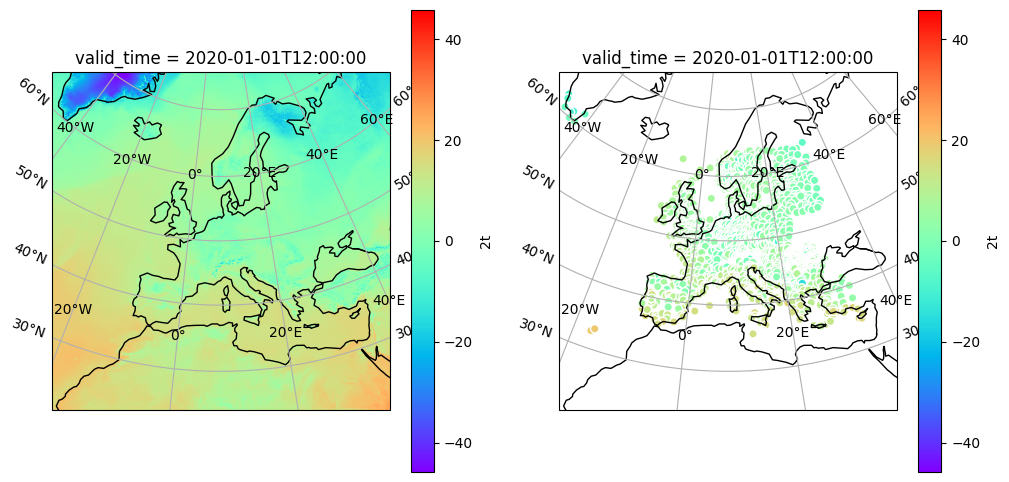

In [16]:
# Now we can plot, leveraging all of xarray's functionality
import matplotlib.pyplot as plt
fig, axs = plt.subplots(1,2,subplot_kw={"projection": crs},figsize=(12,6))
cerra.data["2t"].plot(x="x",y="y",ax=axs[0],cmap="rainbow")
axs[0].coastlines()
axs[0].gridlines(draw_labels=True)

vmin, vmax = axs[0].collections[0].get_clim()
synop.data.isel(valid_time=0).plot.scatter(
    x="longitude",
    y="latitude",
    hue="2t", 
    ax=axs[1], 
    transform=cartopy.crs.PlateCarree(),
    cmap="rainbow",
    vmin=vmin,
    vmax=vmax,
)

axs[1].coastlines()
axs[1].set_extent(list(axs[0].get_extent()),crs=crs)
axs[1].gridlines(draw_labels=True)

### Data homogenization

In [17]:
# The above plot does not tell us much, let's interpolate the data of CERRA to the synop-locations
import homogenization

In [18]:
# Combine the datastores in a dictionary
datastores = {
    "cerra" : cerra,
    "synop" : synop,
}

# Let's bring the datasets to common locations
# The design choise here is to for common_grid_or_points to return a dictionary of xarray.Datasets and not datastores,
# as the type of datastore is changed. E.g. here the CERRA Gridded-Observation datastore has become a Point-Observations datastore
data_interpolated = homogenization.common_grid_or_points(
    datastores=datastores,
    reference_datastore="synop"
)


2025-02-24 15:19:37 - INFO - reference datastore synop is an ObsDatastore
2025-02-24 15:19:37 - INFO - Initializing interpolator
2025-02-24 15:19:37 - INFO - Interpolating to reference points for datastore cerra
2025-02-24 15:19:37 - INFO - Transforming anemoi-datasets xr.DataArray to xr.Dataset, this might take some time.
2025-02-24 15:19:57 - INFO - Selecting all reference points for datastore: synop


In [19]:
#Let's checkout the interpolated CERRA dataset
data_interpolated["cerra"]

<xarray.Dataset> Size: 382kB
Dimensions:          (valid_time: 1, code: 1706)
Coordinates:
  * valid_time       (valid_time) datetime64[ns] 8B 2020-01-01T12:00:00
    x                (code) float64 14kB -1.612e+05 -1.448e+05 ... 1.555e+06
    y                (code) float64 14kB 1.352e+06 1.386e+06 ... 5.83e+05
  * code             (code) int64 14kB 1203 1205 1209 1210 ... 26961 26966 26976
    station_name     (code) <U20 136kB 'Krakenes' ... 'Krasnaja Gora'
    station_country  (code) <U20 136kB 'Norway' 'Norway' ... 'U.S.S.R.(Europe)'
    altitude         (code) float64 14kB nan 38.0 74.0 22.0 ... nan nan nan nan
    latitude         (code) float64 14kB 62.03 62.33 62.18 ... 53.22 52.9 53.02
    longitude        (code) float64 14kB 4.983 5.267 6.067 ... 29.18 30.03 31.6
Data variables:
    2t               (valid_time, code) float64 14kB 7.623 7.957 ... -0.1977
    10si             (valid_time, code) float64 14kB 17.1 20.35 ... 5.719 5.647
Attributes:
    crs:      +proj=lcc +ellps=WGS84 +a=6371229.0 +b=6371229.0 +lon_0=8.0 +la...

2025-02-24 15:20:04 - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x7fb65a2fbd90>
2025-02-24 15:20:06 - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x7fb659c10210>
2025-02-24 15:20:07 - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x7fb65a3af9d0>


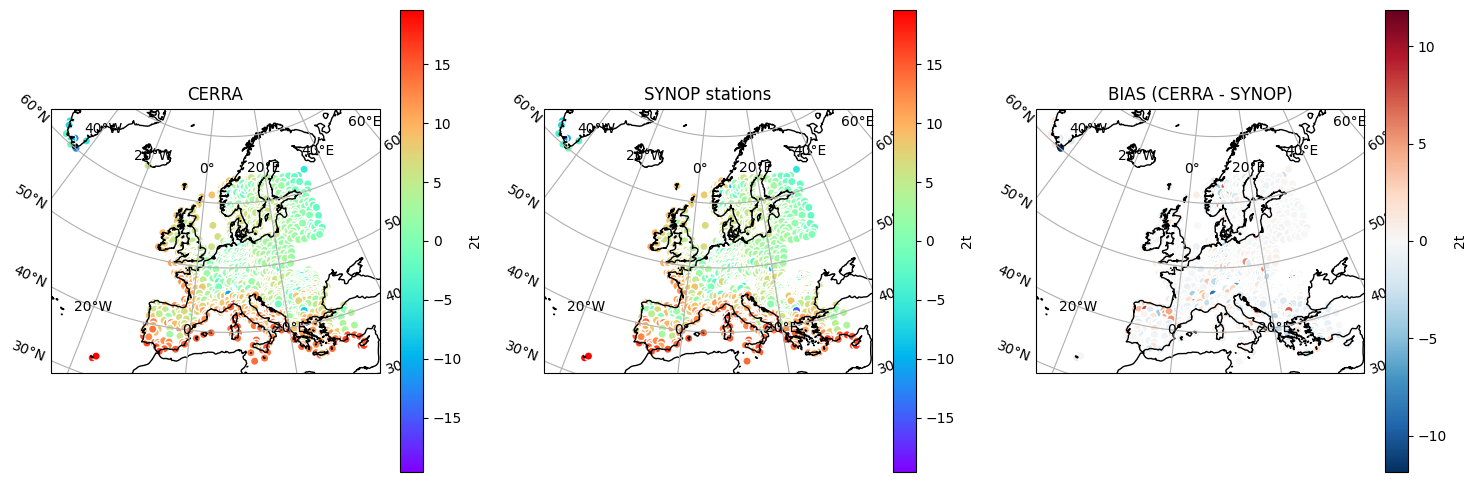

In [20]:
# Let's plot again

fig, axs = plt.subplots(1,3,subplot_kw={"projection": crs},figsize=(18,6))
data_interpolated["cerra"].isel(valid_time=0).plot.scatter(
    x="longitude",
    y="latitude",
    hue="2t", 
    ax=axs[0], 
    transform=cartopy.crs.PlateCarree(),
    cmap="rainbow",
)
axs[0].coastlines()
axs[0].gridlines(draw_labels=True)
axs[0].set_title("CERRA")
vmin, vmax =axs[0].collections[0].get_clim()

data_interpolated["synop"].isel(valid_time=0).plot.scatter(
    x="longitude",
    y="latitude",
    hue="2t", 
    ax=axs[1], 
    transform=cartopy.crs.PlateCarree(),
    cmap="rainbow",
    vmin=vmin,
    vmax=vmax,
)
axs[1].set_title("SYNOP stations")
axs[1].coastlines()
axs[1].gridlines(draw_labels=True)

bias = data_interpolated["cerra"] - data_interpolated["synop"].sel(code=data_interpolated["cerra"].code)
bias.isel(valid_time=0).plot.scatter(
    x="longitude",
    y="latitude",
    hue="2t", 
    ax=axs[2], 
    transform=cartopy.crs.PlateCarree(),
)
axs[2].set_title("BIAS (CERRA - SYNOP)")
axs[2].coastlines()
axs[2].gridlines(draw_labels=True)

It seems CERRA matches closely the SYNOP stations except for mountainous regions. This is due to the difference in altitude of the CERRA orography and the actual height of the SYNOP stations.  
For now, a height correction is not performed during the interpolation.